# Инициализация

Загружаем библиотеки необходимые для выполнения кода ноутбука.

In [2]:
# Убедимся, что работаем в нужном окружении
import sys

print(sys.executable)

/home/mle-user/mle-project-sprint-4-v001/env_recsys_start/bin/python


In [3]:
# Импортируем необходимые библиотеки

import os
import gc
from dotenv import load_dotenv
import boto3
from botocore.exceptions import ClientError

import numpy as np
np.random.seed(42)
import pandas as pd
pd.options.display.max_columns = 100
pd.options.display.max_rows = 64

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("white")
sns.set_theme(style="whitegrid")

import joblib
import scipy
import sklearn.preprocessing
from catboost import CatBoostClassifier, Pool

from pandas.tseries.offsets import MonthEnd

In [4]:
# Загружаем переменные окружения для S3-хранилища

load_dotenv()

os.environ["S3_ENDPOINT_URL"] = "https://storage.yandexcloud.net" 
os.environ["S3_BUCKET_NAME"] = os.getenv("S3_BUCKET_NAME") 
os.environ["AWS_ACCESS_KEY_ID"] = os.getenv("AWS_ACCESS_KEY_ID") 
os.environ["AWS_SECRET_ACCESS_KEY"] = os.getenv("AWS_SECRET_ACCESS_KEY")

In [5]:
# Создаем соединение с S3-хранилищем

session = boto3.session.Session()
s3_client = session.client(
    service_name='s3',
    endpoint_url=os.environ.get('S3_ENDPOINT_URL'),
    aws_access_key_id=os.environ.get('AWS_ACCESS_KEY_ID'),
    aws_secret_access_key=os.environ.get('AWS_SECRET_ACCESS_KEY')
)

# === ЭТАП 1 ===

# Загрузка первичных данных

Загружаем первичные данные из файлов:
- tracks.parquet
- catalog_names.parquet
- interactions.parquet

In [ ]:
tracks = pd.read_parquet("tracks.parquet")
# Проверяем track_id на наличие дубликатов 
print(f"Все track_id уникальны: {tracks['track_id'].nunique() == len(tracks)}")

# Проверяем track_id на наличие отрицательных значений
print(f"Кол-во отрицательных track_id: {(tracks['track_id'] < 0).sum()}")
tracks.info()
tracks.head()

Все track_id уникальны: True
Кол-во отрицательных track_id: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 4 columns):
 #   Column    Non-Null Count    Dtype 
---  ------    --------------    ----- 
 0   track_id  1000000 non-null  int64 
 1   albums    1000000 non-null  object
 2   artists   1000000 non-null  object
 3   genres    1000000 non-null  object
dtypes: int64(1), object(3)
memory usage: 30.5+ MB


,track_id,albums,artists,genres
0,26,"[3, 2490753]",[16],"[11, 21]"
1,38,"[3, 2490753]",[16],"[11, 21]"
2,135,"[12, 214, 2490809]",[84],[11]
3,136,"[12, 214, 2490809]",[84],[11]
4,138,"[12, 214, 322, 72275, 72292, 91199, 213505, 24...",[84],[11]


In [ ]:
catalog_names = pd.read_parquet("catalog_names.parquet")
catalog_names.info()
display(catalog_names.isnull().sum())
catalog_names.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1812471 entries, 0 to 1812470
Data columns (total 3 columns):
 #   Column  Dtype 
---  ------  ----- 
 0   id      int64 
 1   type    object
 2   name    object
dtypes: int64(1), object(2)
memory usage: 41.5+ MB


id      0
type    0
name    0
dtype: int64

,id,type,name
0,3,album,Taller Children
1,12,album,Wild Young Hearts
2,13,album,Lonesome Crow
3,17,album,Graffiti Soul
4,26,album,Blues Six Pack


In [ ]:
# Проверяем id на наличие повторяющихся значений
print(f"Кол-во уникальных id: {catalog_names['id'].nunique()}, общее кол-во строк: {len(catalog_names)}")

# Проверяем id на наличие отрицательных значений
print(f"Кол-во отрицательных id: {(catalog_names['id'] < 0).sum()}")

# Проверяем наличие повторяющихся строк
duplicated_rows_condition = catalog_names.duplicated(catalog_names.columns, keep=False)
print(f"Кол-во повторяющихся строк: {duplicated_rows_condition.sum()}")

Кол-во уникальных id: 1776697, общее кол-во строк: 1812471
Кол-во отрицательных id: 0
Кол-во повторяющихся строк: 0


In [ ]:
# Проверяем наличие повторяющихся id внутри типа album
cat_albums = catalog_names.query("type == 'album'")
print(f"Среди id альбомов нет повторяющихся значений: {cat_albums['id'].nunique() == len(cat_albums)}")

# Проверяем наличие повторяющихся id внутри типа artist
cat_artists = catalog_names.query("type == 'artist'")
print(f"Среди id артистов нет повторяющихся значений: {cat_artists['id'].nunique() == len(cat_artists)}")

# Проверяем наличие повторяющихся id внутри типа genre
cat_genres = catalog_names.query("type == 'genre'")
print(f"Среди id жанров нет повторяющихся значений: {cat_genres['id'].nunique() == len(cat_genres)}")

# Проверяем наличие повторяющихся id внутри типа track
cat_tracks = catalog_names.query("type == 'track'")
print(f"Среди id названий треков нет повторяющихся значений: {cat_tracks['id'].nunique() == len(cat_tracks)}")

Среди id альбомов нет повторяющихся значений: True
Среди id артистов нет повторяющихся значений: True
Среди id жанров нет повторяющихся значений: True
Среди id названий треков нет повторяющихся значений: True


В рамках каждого type все id уникальны

In [ ]:
# Разворачиваем tracks по каталожным ids и переименовываем колонки
tracks_exploded = tracks.explode('albums', ignore_index=True) \
    .explode('artists', ignore_index=True) \
        .explode('genres', ignore_index=True) \
            .rename(columns={'albums':'album_id', 'artists': 'artist_id', 'genres': 'genre_id'})
# Оставляем только треки, у которых заполнены все 3 категории артист/жанр/альбом
id_columns = ['album_id', 'artist_id', 'genre_id']
tracks_exploded = tracks_exploded[~tracks_exploded[id_columns].isnull().any(axis=1)]
tracks_exploded[['album_id', 'artist_id', 'genre_id']] = \
    tracks_exploded[['album_id', 'artist_id', 'genre_id']].astype('int')
tracks_exploded = tracks_exploded \
    .merge(cat_albums[['id', 'name']], how='left', left_on='album_id', right_on='id') \
        .rename(columns={'name': 'album_name'}).drop(columns='id')
tracks_exploded = tracks_exploded \
    .merge(cat_artists[['id', 'name']], how='left', left_on='artist_id', right_on='id') \
        .rename(columns={'name': 'artist_name'}).drop(columns='id')
tracks_exploded = tracks_exploded\
    .merge(cat_genres[['id', 'name']], how='left', left_on='genre_id', right_on='id')\
        .rename(columns={'name': 'genre_name'}).drop(columns='id')
tracks_exploded.drop(columns=['artist_id', 'genre_id', 'album_id'], inplace=True)

In [ ]:
tracks_exploded['track_id'].nunique()

980977

In [ ]:
tracks = tracks_exploded.groupby('track_id') \
    .agg({'album_name': lambda x: x.tolist(), 'artist_name': lambda x: x.tolist(), 'genre_name': lambda x: x.tolist()}) \
        .rename({'album_name': 'albums', 'artist_name': 'artists', 'genre_name': 'genres'}, axis=1) \
            .reset_index()

In [ ]:
# Удаляем повторяющиеся названия в списках каталогов
tracks['albums'] = tracks['albums'].apply(lambda x: list(set(x)))
tracks['artists'] = tracks['artists'].apply(lambda x: list(set(x)))
tracks['genres'] = tracks['genres'].apply(lambda x: list(set(x)))

In [ ]:
tracks = tracks \
    .merge(cat_tracks[['id', 'name']], how='left', left_on='track_id', right_on='id') \
        .drop(columns='id')

In [ ]:
print(f"Кол-во треков без названий: {tracks['name'].isnull().sum()}")
tracks.head()

Кол-во треков без названий: 0


,track_id,albums,artists,genres,name
0,26,[Taller Children],[Elizabeth & the Catapult],"[folk, pop]",Complimentary Me
1,38,[Taller Children],[Elizabeth & the Catapult],"[folk, pop]",Momma's Boy
2,135,[Wild Young Hearts],[Noisettes],[pop],Atticus
3,136,[Wild Young Hearts],[Noisettes],[pop],24 Hours
4,138,"[Don't Upset The Rhythm, Wild Young Hearts, I ...",[Noisettes],[pop],Don't Upset The Rhythm (Go Baby Go)


In [ ]:
print(f"Максимальное значение track_id: {tracks['track_id'].max()}")
print(f"Максимальное значение для int32: {2**32 - 1}")
# Приводим track_id к int32 для экономии памяти
tracks['track_id'] = tracks['track_id'].astype('int32')

Максимальное значение track_id: 101521819
Максимальное значение для int32: 4294967295


In [ ]:
interactions = pd.read_parquet("interactions.parquet")
interactions.info()
display(interactions.isnull().sum())
interactions.head()

<class 'pandas.core.frame.DataFrame'>
Index: 222629898 entries, 0 to 291
Data columns (total 4 columns):
 #   Column      Dtype         
---  ------      -----         
 0   user_id     int32         
 1   track_id    int32         
 2   track_seq   int16         
 3   started_at  datetime64[ns]
dtypes: datetime64[ns](1), int16(1), int32(2)
memory usage: 5.4 GB


user_id       0
track_id      0
track_seq     0
started_at    0
dtype: int64

,user_id,track_id,track_seq,started_at
0,0,99262,1,2022-07-17
1,0,589498,2,2022-07-19
2,0,590262,3,2022-07-21
3,0,590303,4,2022-07-22
4,0,590692,5,2022-07-22


In [ ]:
# Фильтруем треки в таблице взаимодействий
interactions = interactions[interactions['track_id'].isin(tracks['track_id'])]

# Смотрим, сколько осталось событий после удаления
len(interactions)

222184449

Удалим часть данных для экономии памяти
Я вижу два варианта. Удалять треки у пользователей или удалять самих пользователей целиком. Каждый вариант имеет свои плюсы и минусы. Я хочу оставить треть текущего объема для комфортного взаимодействия и обучения в условиях ограниченных ресурсов (в реальных кейсах обычно не трудно выбить себе тачки с большим кол-вом оперативной памяти).
Скомбинирую эти подходы. Удалю 1/3 юзеров, далее оставлю каждый второй трек у каждого

In [ ]:
unique_users = interactions['user_id'].unique()
sample_users = pd.Series(unique_users).sample(frac=2/3, random_state=42)

interactions = interactions[interactions['user_id'].isin(sample_users)]
interactions = interactions[(interactions['track_seq'] - 1) % 2 == 0]
len(interactions)

74270649

In [ ]:
interactions.info()

<class 'pandas.core.frame.DataFrame'>
Index: 74270649 entries, 0 to 290
Data columns (total 4 columns):
 #   Column      Dtype         
---  ------      -----         
 0   user_id     int32         
 1   track_id    int32         
 2   track_seq   int16         
 3   started_at  datetime64[ns]
dtypes: datetime64[ns](1), int16(1), int32(2)
memory usage: 1.8 GB


In [ ]:
duplicates_condition = interactions.duplicated(['user_id', 'track_id'], keep=False)
print(f"Кол-во повторяющихся пар user_id, track_id: {duplicates_condition.sum()}")

Кол-во повторяющихся пар user_id, track_id: 0


In [ ]:
# Переименовываем колонки
tracks.rename(columns={'track_id': 'item_id'}, inplace=True)
interactions.rename(columns={'track_id': 'item_id'}, inplace=True)

In [ ]:
items = tracks.copy()
events = interactions.copy()
del tracks
del interactions

In [ ]:
del catalog_names
gc.collect()

0

In [ ]:
# Сохраняем треки и события в 2-х новых файлах
items.to_parquet("items.parquet")
events.to_parquet("events.parquet")

# Выводы

Приведём выводы по первому знакомству с данными:
- есть ли с данными явные проблемы,
- какие корректирующие действия (в целом) были предприняты.

* Сильных проблем с данными не было. Пропуски дубликаты не обнаружены или корректны. Для экономии ресурсов и упрощения расчетов оставлены только полностью заполненные треки по столбцам жанр, артист, альбом, название трека (потери 2%). 
* Удалена 1/3 пользователей из взаимодействий, оставлен только каждый второй трек у пользователя. Сделно для экономии ресурсов (потери примерно 66% взаимодействий)
* Преобразованы и предобработаны данные о треках и прослушивания. Результаты в items.parquet и events.parquet.

# === ЭТАП 2 ===

# EDA

Имеет смысл перезапустить ядро, чтобы почистить память. gc.collect() не всегда целиком справляется. После перезапускать выполнить блок "Инициализация"

In [ ]:
items = pd.read_parquet("items.parquet")
events = pd.read_parquet("events.parquet")

Распределение количества прослушанных треков.

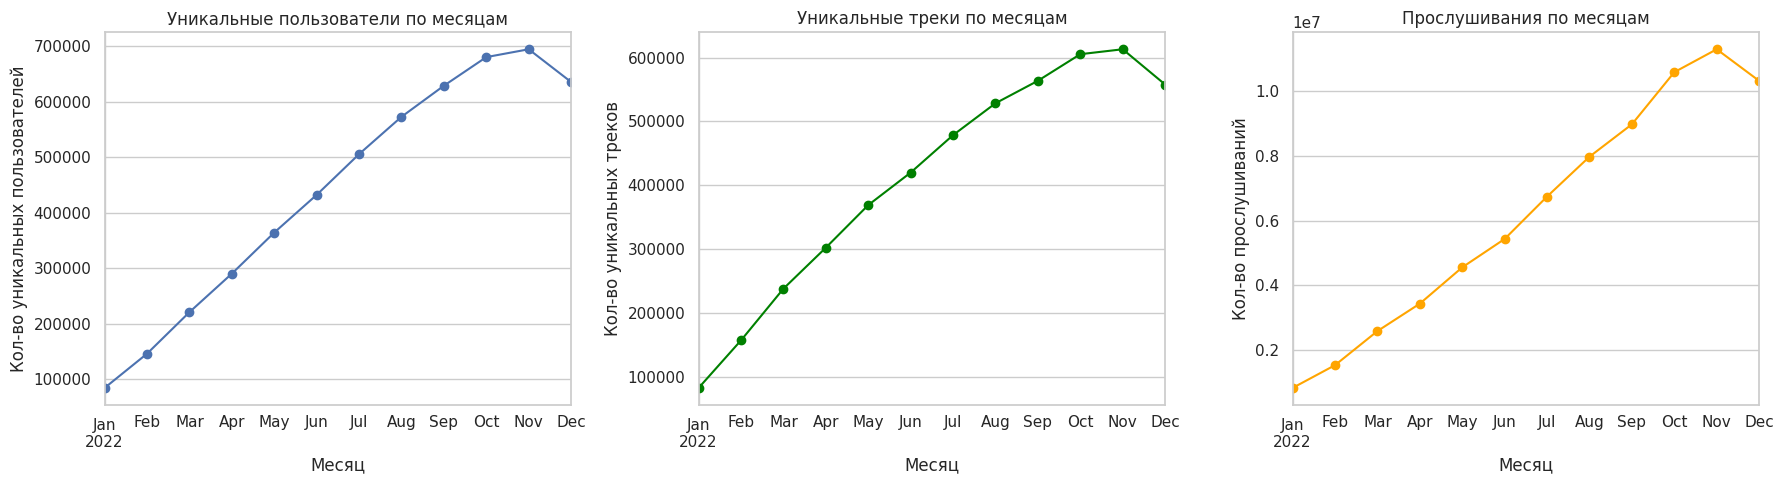

In [ ]:
events['year_month'] = events['started_at'].dt.to_period('M')
users_per_month = events.groupby('year_month')['user_id'].nunique()
listens_per_month = events.groupby('year_month').size()
tracks_per_month = events.groupby('year_month')['item_id'].nunique()

plt.figure(figsize=(18, 5))

# График уникальных пользователей
plt.subplot(1, 3, 1)
users_per_month.plot(marker='o')
plt.title('Уникальные пользователи по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Кол-во уникальных пользователей')
plt.grid(True)

# График уникальных треков
plt.subplot(1, 3, 2)
tracks_per_month.plot(marker='o', color='green')
plt.title('Уникальные треки по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Кол-во уникальных треков')
plt.grid(True)

# График прослушиваний
plt.subplot(1, 3, 3)
listens_per_month.plot(marker='o', color='orange')
plt.title('Прослушивания по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Кол-во прослушиваний')
plt.grid(True)

plt.tight_layout()
plt.show()


Виден постепенный рост всех графиков. Популярность сервиса росла (при условии, что выборка пользователей случайная из всех пользователей за рассматриваемый период), в декабре начала несколько снижаться.

In [ ]:
events['started_at'].max() #декабрь полный месяц, написанное выше корректно

Timestamp('2022-12-31 00:00:00')

In [ ]:
# Агрегируем треки по всем событиям
agg_items = events.groupby("item_id").agg(plays=("started_at", "count")).reset_index()
agg_items['plays'].describe()

count    959785.000000
mean         77.382590
std         469.066879
min           1.000000
25%           3.000000
50%           7.000000
75%          24.000000
max       39207.000000
Name: plays, dtype: float64

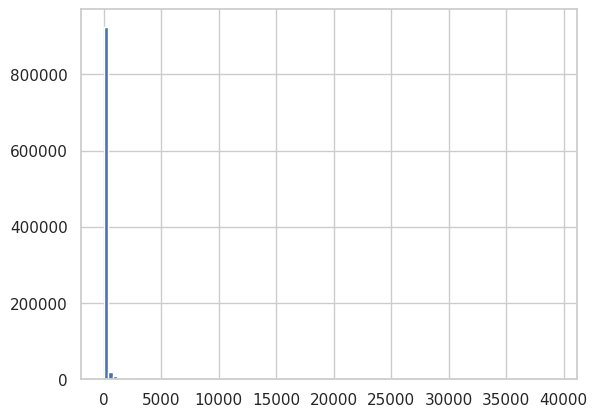

<Axes: >

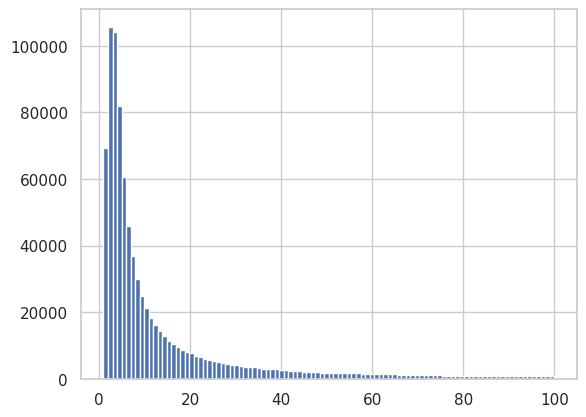

In [ ]:
agg_items['plays'].hist(bins = 100)
plt.show()
agg_items.query('plays <= 100')['plays'].hist(bins = 100)

In [ ]:
percentiles = np.arange(75, 100.1, 2.5)
percentile_values = np.percentile(agg_items['plays'], percentiles)
pd.DataFrame({'percentile': percentiles, 'plays': percentile_values})

,percentile,plays
0,75.0,24.0
1,77.5,29.0
2,80.0,35.0
3,82.5,44.0
4,85.0,57.0
5,87.5,76.0
6,90.0,107.0
7,92.5,160.0
8,95.0,266.0
9,97.5,578.0


Есть некоторый правый хвост. По describe и гистограммам видно, что большинство треков имеют довольно мало прослушиваний (медиана = 7, 75-ый процентиль = 24, 90-ый процентиль = 107)

Наиболее популярные треки

В дальнейшем предполагается использовать популярные треки в качестве рекомендация для холодных юзеров. Поэтому сначала произведем разбиение данных, а потом проведем EDA. Это не должно сильно его исказить, но мы решим проблему подглядывания

In [ ]:
train_test_global_time_split_date = pd.to_datetime("2022-12-16")

train_test_global_time_split_idx = events["started_at"] < train_test_global_time_split_date
events_train = events[train_test_global_time_split_idx]
events_test = events[~train_test_global_time_split_idx]

In [ ]:
pop_items = events_train \
    .groupby("item_id").agg(plays=("started_at", "count"), users=("user_id", "nunique")).reset_index()

# Сортируем по убыванию кол-ва прослушиваний, а при их равенстве - по убыванию уникальных пользователей
pop_items = pop_items.sort_values(['plays', 'users'], ascending=[False, False])

# Выбираем первые 100 самых прослушиваемых треков 
top_k_pop_items = pop_items[:100].reset_index().drop(columns='index')

In [ ]:
# Добавляем колонки с названиями всех каталожных единиц
top_k_pop_items = top_k_pop_items \
    .merge(items[['item_id', 'name', 'genres', 'artists', 'albums']], how='inner', on='item_id')

# Добавляем колонку rank
top_k_pop_items = top_k_pop_items.reset_index().rename(columns={'index': 'rank'})
top_k_pop_items['rank'] += 1

top_k_pop_items

,rank,item_id,plays,users,name,genres,artists,albums
0,1,53404,38805,38805,Smells Like Teen Spirit,"[alternative, rock, allrock]",[Nirvana],"[Nirvana, Nevermind, Skiing Music, Smells Like..."
1,2,178529,34749,34749,Numb,"[metal, numetal]",[Linkin Park],"[Meteora, 00s Rock Anthems]"
2,3,33311009,34019,34019,Believer,"[rock, allrock]",[Imagine Dragons],"[Handball Wam Up, New Years Eve 2022, Empoweri..."
3,4,35505245,32359,32359,I Got Love,"[rusrap, rap]","[Рем Дигга, Miyagi & Эндшпиль]",[I Got Love]
4,5,24692821,28578,28578,Way Down We Go,[indie],[KALEO],"[Way down We Go, Summer Music 2017, A/B, Chill..."
...,...,...,...,...,...,...,...,...
95,96,29175370,16075,16075,Рапапам,"[rusrap, rap]","[9 грамм, Miyagi & Эндшпиль]",[Рапапам]
96,97,56776952,16020,16020,2 типа людей,"[rusrap, rap]",[Макс Корж],[2 типа людей]
97,98,1710810,15961,15961,Another One Bites The Dust,"[soundtrack, rock, allrock, films]",[Queen],"[The Game, Bohemian Rhapsody, The Platinum Col..."
98,99,68562711,15850,15850,Сияй,"[pop, ruspop]",[Ramil'],[Сияй]


In [ ]:
top_k_pop_items.to_parquet('top_popular.parquet')

Наиболее популярные жанры

Среди топ треков

In [ ]:
# Функция для извлечения жанров из треков
def get_genres(items):

    """ 
    Извлекает жанры из треков и считает, сколько раз встречается каждый жанр.
    """    
    genres_counter = {}
    
    for k, v in items.iterrows():
        if v["genres"] is None: # После предобработки NA быть не может, оставили для общего случая
            continue
        
        genres = list(v["genres"])

        for genre in genres:
            try:
                genres_counter[genre] += v['plays']
            except KeyError:
                genres_counter[genre] = v['plays']

    genres = pd.Series(genres_counter, name="items_count")
    genres = genres.to_frame()
    genres = genres.reset_index().rename(columns={"index": "name"})
    genres.index.name = "genre_id"

    return genres

/home/mle-user/mle-project-sprint-4-v001/env_recsys_start/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/mle-user/mle-project-sprint-4-v001/env_recsys_start/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/mle-user/mle-project-sprint-4-v001/env_recsys_start/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


Text(0.5, 1.0, 'Top 15 most played genres')

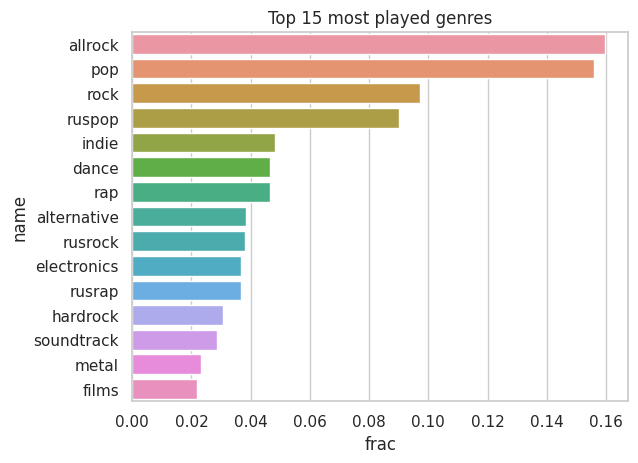

In [ ]:
# Извлекаем жанры из самых популярных треков и считаем score для каждого жанра, как долю от общего кол-ва треков
n=15
top_k_pop_items_genres = get_genres(top_k_pop_items)
top_k_pop_items_genres["frac"] = top_k_pop_items_genres["items_count"] / top_k_pop_items_genres["items_count"].sum()
sns.barplot(data=top_k_pop_items_genres.sort_values(by="frac", ascending=False).head(n), x='frac', y='name').set_title(f"Top {n} most played genres")

In [ ]:
# Извлекаем жанры по всем трекам
genres = get_genres(pop_items.merge(items[['item_id', 'name', 'genres', 'artists', 'albums']], how='inner', on='item_id'))
genres["score"] = genres["items_count"] / genres["items_count"].sum()
genres.sort_values(by="score", ascending=False)

,name,items_count,score
genre_id,,,
8,pop,17238700,1.461784e-01
6,rap,11732426,9.948705e-02
2,allrock,9946819,8.434570e-02
11,ruspop,8023020,6.803252e-02
5,rusrap,7792297,6.607607e-02
...,...,...,...
135,news,45,3.815849e-07
132,society,42,3.561459e-07
131,religion,26,2.204713e-07


In [ ]:
genres.to_parquet('genres.parquet')

Треки, которые никто не прослушал

In [ ]:
# Уникальные id всех треков
all_items_ids = set(items['item_id'])
        
# Уникальные id только прослушанных треков
played_items_ids = set(events['item_id'].unique()) 

# Треки, которые есть в items, но нет в events
not_played_items_ids = list(all_items_ids - played_items_ids)
print(f"Кол-во непрослушанных треков: {len(not_played_items_ids)}")

Кол-во непрослушанных треков: 21192


# Сохранение данных

Сохраним данные в двух файлах в персональном S3-бакете по пути `recsys/data/`:
- `items.parquet` — все данные о музыкальных треках,
- `events.parquet` — все данные о взаимодействиях.

In [ ]:
# Сохраняем файлы в S3-хранилище
s3_client.upload_file('items.parquet', os.environ.get("S3_BUCKET_NAME"), 'recsys/data/items.parquet')
s3_client.upload_file('events.parquet', os.environ.get("S3_BUCKET_NAME"), 'recsys/data/events.parquet')

# Очистка памяти

Здесь, может понадобится очистка памяти для высвобождения ресурсов для выполнения кода ниже. 

Приведите соответствующие код, комментарии, например:
- код для удаление более ненужных переменных,
- комментарий, что следует перезапустить kernel, выполнить такие-то начальные секции и продолжить с этапа 3.

Перезапустите ядро и выполните блок "Инициализация" для очистки памяти

# === ЭТАП 3 ===

# Загрузка данных

Если необходимо, то загружаем items.parquet, events.parquet.

In [8]:
items = pd.read_parquet("items.parquet")
events = pd.read_parquet("events.parquet")

# Разбиение данных

Разбиваем данные на тренировочную, тестовую выборки.

In [ ]:
# Зададим точку разбиения
train_test_global_time_split_date = pd.to_datetime("2022-12-16")

train_test_global_time_split_idx = events["started_at"] < train_test_global_time_split_date
events_train = events[train_test_global_time_split_idx]
events_test = events[~train_test_global_time_split_idx]

# Топ популярных

Рассчитаем рекомендации как топ популярных.

In [ ]:
# Загружаем топ-100 самых прослушиваемых треков
top_k_pop_items = pd.read_parquet("top_popular.parquet")
top_k_pop_items.head()

,rank,item_id,plays,users,name,genres,artists,albums
0,1,53404,38805,38805,Smells Like Teen Spirit,"[alternative, rock, allrock]",[Nirvana],"[Nirvana, Nevermind, Skiing Music, Smells Like..."
1,2,178529,34749,34749,Numb,"[metal, numetal]",[Linkin Park],"[Meteora, 00s Rock Anthems]"
2,3,33311009,34019,34019,Believer,"[rock, allrock]",[Imagine Dragons],"[Handball Wam Up, New Years Eve 2022, Empoweri..."
3,4,35505245,32359,32359,I Got Love,"[rusrap, rap]","[Рем Дигга, Miyagi & Эндшпиль]",[I Got Love]
4,5,24692821,28578,28578,Way Down We Go,[indie],[KALEO],"[Way down We Go, Summer Music 2017, A/B, Chill..."


In [ ]:
# Идентификаторы уникальных пользователей в train и test
users_train = events_train["user_id"].drop_duplicates()
users_test = events_test["user_id"].drop_duplicates()

# Идентификаторы "холодных" пользователей
cold_users = users_test[~users_test.isin(users_train)]
print(f"Кол-во холодных пользователей: {len(cold_users)}")

Кол-во холодных пользователей: 20336


In [ ]:
# Формируем бинарную колонку match для подсчета числа совпадений

top_k_pop_items['match'] = 1

cold_users_events = \
    events_test[events_test["user_id"].isin(cold_users)] \
        .merge(top_k_pop_items[['item_id', 'match']], on="item_id", how="left")

cold_users_events['match'].fillna(0, inplace=True)

In [ ]:
# Доля треков "холодных" пользователей, совпавших с рекомендациями по умолчанию
cold_users_events_match_share = cold_users_events['match'].sum() / len(cold_users_events)
cold_users_events_match_share

0.05536927340905386

In [ ]:
# Группируем холодных пользователей по их id
cold_users_hit_ratio = cold_users_events.groupby("user_id").agg(hits=("match", 'sum'))
print(f"Доля холодных пользователей без релевантных рекомендаций: {(cold_users_hit_ratio == 0).mean().iat[0]:.3f}")
print(f"Среднее покрытие холодных пользователей: {cold_users_hit_ratio[cold_users_hit_ratio != 0].mean().iat[0]:.3f}")

Доля холодных пользователей без релевантных рекомендаций: 0.554
Среднее покрытие холодных пользователей: 2.246


45% холодных пользователей на тестовой выборке имели прослушивания среди топ100 популярных треков. Результат неплохой. В среднем 2.2 прослушивания на тех, кто получил релевантные рекомендации

# Персональные

Рассчитаем персональные рекомендации.

In [9]:
# Перекодируем идентификаторы пользователей: 
# из имеющихся в последовательность 0, 1, 2, ...
user_encoder = sklearn.preprocessing.LabelEncoder()
user_encoder.fit(events["user_id"])
events_train["user_id_enc"] = user_encoder.transform(events_train["user_id"])
events_test["user_id_enc"] = user_encoder.transform(events_test["user_id"])

# Перекодируем идентификаторы объектов: 
# из имеющихся в последовательность 0, 1, 2, ...
item_encoder = sklearn.preprocessing.LabelEncoder()
item_encoder.fit(items["item_id"])
items["item_id_enc"] = item_encoder.transform(items["item_id"])
events_train = events_train.merge(items[["item_id", "item_id_enc"]], on="item_id", how='left')
events_test = events_test.merge(items[["item_id", "item_id_enc"]], on="item_id", how='left')

In [ ]:
# Формируем колонку target (1 - трек прослушан, 0 - нет)
events_train['target'] = 1

# Создаём sparse-матрицу формата CSR 
user_item_matrix_train = scipy.sparse.csr_matrix((
    events_train["target"],
    (events_train['user_id_enc'], events_train['item_id_enc'])),
    dtype=np.int8)

In [ ]:
# Код для создания и тренировки модели
from implicit.als import AlternatingLeastSquares

als_model = AlternatingLeastSquares(factors=50, iterations=50, regularization=0.05, random_state=0)
als_model.fit(user_item_matrix_train)

/home/mle-user/mle-project-sprint-4-v001/env_recsys_start/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/mle-user/mle-project-sprint-4-v001/env_recsys_start/lib/python3.10/site-packages/implicit/cpu/als.py:95: RuntimeWarning: OpenBLAS is configured to use 4 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()
100%|██████████| 50/50 [16:48<00:00, 20.17s/it]


In [ ]:
# Сохраняем als-модель в файл
os.makedirs('models/', exist_ok=True)
with open('models/als_model.pkl', 'wb') as fd:
    joblib.dump(als_model, fd)

In [ ]:
def get_recommendations_als(user_item_matrix, als_model, user_id, user_encoder, item_encoder, include_seen=True, n=5):
    """
    Возвращает отранжированные рекомендации для заданного пользователя
    """
    user_id_enc = user_encoder.transform([user_id])[0]
    recommendations = als_model.recommend(
         user_id_enc, 
         user_item_matrix[user_id_enc], 
         filter_already_liked_items=not include_seen,
         N=n)
    recommendations = pd.DataFrame({"item_id_enc": recommendations[0], "score": recommendations[1]})
    recommendations["item_id"] = item_encoder.inverse_transform(recommendations["item_id_enc"])
    
    return recommendations

In [ ]:
# Выберем произвольного пользователя из тренировочной выборки ("прошлого")
user_id = events_train['user_id'].sample().iat[0]
print(f"user_id: {user_id}")

print("Последние события:")
user_history = (
    events_train
    .query("user_id == @user_id")
    .merge(items.set_index("item_id")[["name", "genres", "albums", "artists"]], on="item_id")
)
user_history_to_print = user_history[["item_id", "name", "genres", "albums", "artists"]].tail(10)
display(user_history_to_print)

print("Рекомендации:")
user_recommendations = get_recommendations_als(user_item_matrix_train, als_model, user_id, user_encoder, item_encoder, include_seen=True, n=10)
user_recommendations = user_recommendations.merge(items.set_index("item_id")[["name", "genres", "albums", "artists"]], on="item_id")
user_recommendations_to_print = \
    user_recommendations[["item_id", "name", "genres", "albums", "artists", "score"]].head(10)
display(user_recommendations_to_print)

user_id: 30157
Последние события:


,item_id,name,genres,albums,artists
25,38666504,Если вдруг,"[pop, ruspop]",[Если вдруг],[Sevak]
26,39544459,Johnny B.,"[foreignrap, rap]",[It Ain't Over],[Down Low]
27,39553829,Goodbye,"[disco, pop]",[Goodbye],[Savage]
28,41325607,Остаться с тобой,"[pop, ruspop]",[Остаться с тобой],"[Filatov & Karas, Виктор Цой]"
29,44279380,Плакала,"[dance, pop]","[Karma, Ethno Beat, Cry, Fresh Dance January 2...",[KAZKA]
30,52231004,Лучшая на свете,"[rusestrada, estrada]",[Лучший день],[Стас Михайлов]
31,53117514,Прочь,"[pop, ruspop]",[Прочь],"[TERNOVOY, AMCHI]"
32,57392782,Как ты там?,[dance],[Как ты там?],"[Андрей Леницкий, Nebezao]"
33,62112435,Ты мой кайф,"[rusrap, rap]","[СОЮЗ 63, Ты мой кайф]",[Джаро & Ханза]
34,65260834,Между мной и тобой,"[pop, ruspop]",[Между мной и тобой],[Оскар]


Рекомендации:


,item_id,name,genres,albums,artists,score
0,45499814,Life,"[pop, ruspop]","[Winter Cafe 2019, Vinyl #1, Vinyl #1. Deluxe ...",[Zivert],0.092839
1,49961817,Грустный дэнс,"[pop, ruspop]","[Грустный дэнс, Spring Music 2019, 7 (Part 1)]","[Артём Качер, Artik & Asti]",0.083431
2,19167393,Ghmorni,"[folk, eastern]","[Myriam, Moscow Orient Beat]",[Myriam Fares],0.071751
3,795836,Shape Of My Heart,"[rock, allrock, pop]","[25 Years, Сентиментальные рок-песни, The Best...",[Sting],0.071359
4,10216,Wind Of Change,"[hardrock, allrock]","[Rock Internacional, Born In The 90s Forever Y...",[Scorpions],0.068812
5,4447862,Voyage Voyage,[estrada],"[Best Of Peters Pop Show, I Love 80's, I Love ...",[Desireless],0.068348
6,2166480,You're a Woman,[pop],"[Hot Girls, Bad Boys]",[Bad Boys Blue],0.067075
7,39946957,Зелёные волны,"[pop, ruspop]",[Сияй],[Zivert],0.066607
8,1721,Stop,[pop],"[Rock Lovin, This Is The Sound Of...80s, 100 8...","[Sam Brown, Pete Brown]",0.065981
9,15495586,Lily was here,"[estrada, relax, pop]","[La compilation 80, 50 slows, Saint Valentin -...",[Universal Sound Machine],0.061994


Я не очень силен в музыке, но вроде бы рекомендации неплохие

In [ ]:
# Получаем список всех возможных user_id (перекодированных)
user_ids_encoded = range(len(user_encoder.classes_))

# Получаем рекомендации для всех пользователей
als_recommendations = als_model.recommend(
    user_ids_encoded, 
    user_item_matrix_train[user_ids_encoded], 
    filter_already_liked_items=False, 
    N=50)

#Ячейка случайно была перезапущена, она выполняется очень долго, я ее перезапустил с заглушкой. ниже видно, что рекомендации были посчитаны

In [ ]:
# преобразуем полученные рекомендации в табличный формат
item_ids_enc = als_recommendations[0]
als_scores = als_recommendations[1]

als_recommendations = pd.DataFrame({
    "user_id_enc": user_ids_encoded,
    "item_id_enc": item_ids_enc.tolist(), 
    "score": als_scores.tolist()})
als_recommendations = als_recommendations.explode(["item_id_enc", "score"], ignore_index=True)

# приводим типы данных
als_recommendations["item_id_enc"] = als_recommendations["item_id_enc"].astype("int")
als_recommendations["score"] = als_recommendations["score"].astype("float")

# получаем изначальные идентификаторы
als_recommendations["user_id"] = user_encoder.inverse_transform(als_recommendations["user_id_enc"])
als_recommendations["item_id"] = item_encoder.inverse_transform(als_recommendations["item_id_enc"])
als_recommendations = als_recommendations.drop(columns=["user_id_enc", "item_id_enc"])

In [ ]:
# Смотрим, что получилось
als_recommendations = als_recommendations[["user_id", "item_id", "score"]]
als_recommendations

,user_id,item_id,score
0,0,795836,0.017031
1,0,18860,0.009272
2,0,597196,0.008637
3,0,51241318,0.008103
4,0,29213451,0.008057
...,...,...,...
45757395,1374582,57284734,0.059960
45757396,1374582,48464196,0.059729
45757397,1374582,68934188,0.059631
45757398,1374582,56920237,0.059601


In [ ]:
als_recommendations.to_parquet("personal_als.parquet")

In [12]:
als_recommendations = pd.read_parquet('personal_als.parquet')

In [13]:
cov_items = als_recommendations['item_id'].nunique() / len(items) 
print(cov_items)

0.0057167497301159964


In [ ]:
# разметим каждую рекомендацию признаком played
events_train["played"] = True
als_recommendations = als_recommendations \
    .merge(events_train[['played', "user_id", "item_id"]], on=["user_id", "item_id"], how="left")
als_recommendations["played"] = als_recommendations["played"].fillna(False).astype("bool")

# проставим ранги
als_recommendations = als_recommendations.sort_values(by='score', ascending=False) 
als_recommendations["rank"] = als_recommendations.groupby("user_id").cumcount() + 1

# посчитаем novelty по пользователям
novelty_5 = (1 - als_recommendations.query("rank <= 5").groupby("user_id")["played"].mean())

# посчитаем средний novelty
novelty_5_mean = novelty_5.mean()
print(novelty_5_mean)

0.7475645469366704


In [ ]:
def process_events_recs_for_binary_metrics(events_train, events_test, recs, top_k=None):

    """
    размечает пары <user_id, item_id> для общего множества пользователей признаками
    - gt (ground truth)
    - pr (prediction)
    top_k: расчёт ведётся только для top k-рекомендаций
    """

    events_test["gt"] = True
    common_users = set(events_test["user_id"]) & set(recs["user_id"])

    print(f"Common users: {len(common_users)}")
    
    events_for_common_users = events_test[events_test["user_id"].isin(common_users)].copy()
    recs_for_common_users = recs[recs["user_id"].isin(common_users)].copy()

    recs_for_common_users = recs_for_common_users.sort_values(["user_id", "score"], ascending=[True, False])

    # оставляет только те item_id, которые были в events_train, 
    # т. к. модель не имела возможности давать рекомендации для новых айтемов
    events_for_common_users = events_for_common_users[events_for_common_users["item_id"].isin(events_train["item_id"].unique())]

    if top_k is not None:
        recs_for_common_users = recs_for_common_users.groupby("user_id").head(top_k)
    
    events_recs_common = events_for_common_users[["user_id", "item_id", "gt"]].merge(
        recs_for_common_users[["user_id", "item_id", "score"]], 
        on=["user_id", "item_id"], how="outer")    

    events_recs_common["gt"] = events_recs_common["gt"].fillna(False)
    events_recs_common["pr"] = ~events_recs_common["score"].isnull()
    
    events_recs_common["tp"] = events_recs_common["gt"] & events_recs_common["pr"]
    events_recs_common["fp"] = ~events_recs_common["gt"] & events_recs_common["pr"]
    events_recs_common["fn"] = events_recs_common["gt"] & ~events_recs_common["pr"]

    return events_recs_common

In [ ]:
events_recs_for_binary_metrics = process_events_recs_for_binary_metrics(events_train,
                                                                        events_test, 
                                                                        als_recommendations,
                                                                        top_k=5)

Common users: 479088


In [ ]:
def compute_cls_metrics(events_recs_for_binary_metrics):
    
    groupper = events_recs_for_binary_metrics.groupby("user_id")

    # precision = tp / (tp + fp)
    precision = groupper["tp"].sum() / (groupper["tp"].sum() + groupper["fp"].sum())
    precision = precision.fillna(0).mean()
    
    # recall = tp / (tp + fn)
    recall = groupper["tp"].sum() / (groupper["tp"].sum() + groupper["fn"].sum()) 
    recall = recall.fillna(0).mean()

    return precision, recall

In [ ]:
precision, recall = compute_cls_metrics(events_recs_for_binary_metrics)
print(precision, recall)

0.0033601342550846603 0.004430902584470434


Метрики на основе популярных треков в качестве baseline

In [ ]:
# Каждому юзеру рекомендуем top-5 популярных треков
# Для экономии ресурсов берем ограниченное кол-во юзеров из test 

top_k = 5
users_num = 50000
top_pop_recs = pd.DataFrame({'user_id': events_test['user_id'].unique()[:users_num]})
top_pop_recs['item_id'] = top_pop_recs.apply(lambda x: list(top_k_pop_items['item_id'][:top_k]), axis=1)

top_k_pop_items['score'] = top_k_pop_items['plays'] / top_k_pop_items['plays'].sum()

top_pop_recs['score'] = top_pop_recs.apply(lambda x: list(top_k_pop_items['score'][:top_k]), axis=1)
top_pop_recs = top_pop_recs.explode(['item_id', 'score'], ignore_index=True)

In [ ]:
# Считаем TP, FP и FN для каждой пары user_id, item_id для рекомендаций на основе топ популярных треков
events_top_pop_recs_for_binary_metrics = process_events_recs_for_binary_metrics(events_train,
                                                                                events_test, 
                                                                                top_pop_recs,
                                                                                top_k=5)

Common users: 50000


In [ ]:
# Считаем precision, recall
precision_baseline_2, recall_baseline_2 = compute_cls_metrics(events_top_pop_recs_for_binary_metrics)
print(precision_baseline_2, recall_baseline_2)

0.002076 0.001362972685084548


Построим матрицу итем - жанр

In [ ]:
genres = pd.read_parquet('genres.parquet')
genres.head()

,name,items_count,score
genre_id,,,
0,alternative,3224454,0.027342
1,rock,4135067,0.035064
2,allrock,9946819,0.084346
3,metal,3987078,0.033809
4,numetal,761030,0.006453


In [ ]:
def get_item2genre_matrix(genres, items):

    genre_names_to_id = genres.reset_index().set_index("name")["genre_id"].to_dict()
    
    # list to build CSR matrix
    genres_csr_data = []
    genres_csr_row_idx = []
    genres_csr_col_idx = []
    
    for item_idx, (k, v) in enumerate(items.iterrows()):
        if v["genres"] is None: # После предобработки NA быть не может, оставили для общего случая
            continue
        
        item_genres = list(v["genres"])
        
        for genre_name in item_genres:
            genre_idx = genre_names_to_id[genre_name]
            genres_csr_data.append(1)
            genres_csr_row_idx.append(item_idx)
            genres_csr_col_idx.append(genre_idx)

    genres_csr = scipy.sparse.csr_matrix((genres_csr_data, (genres_csr_row_idx, genres_csr_col_idx)), \
                                         shape=(len(items), len(genres)))
    
    # нормализуем, чтобы сумма оценок принадлежности к жанрам была равна 1
    genres_csr = sklearn.preprocessing.normalize(genres_csr, norm='l1', axis=1)
    
    return genres_csr

In [ ]:
items = items.sort_values(by="item_id_enc")
all_items_genres_csr = get_item2genre_matrix(genres, items)

In [ ]:
# Сохраняем csr-матрицу треки-жанры
scipy.sparse.save_npz('all_items_genres_csr.npz', all_items_genres_csr)

# Похожие

Рассчитаем похожие, они позже пригодятся для онлайн-рекомендаций.

In [ ]:
# Загружаем ALS-модель
with open('models/als_model.pkl', 'rb') as fd:
    als_model = joblib.load(fd)

In [ ]:
# Получим энкодированные идентификаторы объектов в events_train
train_item_ids_enc = events_train['item_id_enc'].unique() 

max_similar_items = 10

# получаем списки похожих объектов, используя ранее полученную ALS-модель
# метод similar_items возвращает и сам объект, как наиболее похожий
# этот объект мы позже отфильтруем, но сейчас запросим на 1 больше
similar_items = als_model.similar_items(train_item_ids_enc, N=max_similar_items+1)

# преобразуем полученные списки в табличный формат
sim_item_item_ids_enc = similar_items[0]
sim_item_scores = similar_items[1]

similar_items = pd.DataFrame({
    "item_id_enc": train_item_ids_enc,
    "sim_item_id_enc": sim_item_item_ids_enc.tolist(), 
    "score": sim_item_scores.tolist()}) 
similar_items = similar_items.explode(['sim_item_id_enc', 'score'], ignore_index=True) 

# приводим типы данных
similar_items["sim_item_id_enc"] = similar_items["sim_item_id_enc"].astype('int') 
similar_items["score"] = similar_items["score"].astype("float")

# получаем изначальные идентификаторы
similar_items["item_id_1"] = item_encoder.inverse_transform(similar_items["item_id_enc"]) 
similar_items["item_id_2"] = item_encoder.inverse_transform(similar_items["sim_item_id  _enc"]) 
similar_items = similar_items.drop(columns=["item_id_enc", "sim_item_id_enc"])

# убираем пары с одинаковыми объектами
similar_items = similar_items.query("item_id_1 != item_id_2")

In [ ]:
# Смотрим результат
similar_items.head()

,score,item_id_1,item_id_2
1,0.943115,99262,99245
2,0.926770,99262,99257
3,0.921854,99262,4637878
4,0.919344,99262,33882127
5,0.917650,99262,99254


In [ ]:
# Сохраняем полученные рекомендации в файл
similar_items.to_parquet("similar.parquet")

In [ ]:
def print_sim_items(item_id, similar_items):
    item_columns_to_use = ["item_id", "name", "genres", "artists", "albums"]
    
    item_id_1 = items.query("item_id == @item_id")[item_columns_to_use]
    display(item_id_1)
    
    si = similar_items.query("item_id_1 == @item_id")
    si = si.merge(items[item_columns_to_use].set_index("item_id"), left_on="item_id_2", right_index=True)
    display(si)

In [ ]:
# Задаем произвольный трек
item_id = similar_items['item_id_1'].sample().iat[0]

# Смотрим похожие треки
print_sim_items(item_id, similar_items)

,item_id,name,genres,artists,albums
190862,6098584,Улыбка,"[forchildren, children]",[Клара Румянова],[Песни Михаила Пляцковского]


,score,item_id_1,item_id_2,name,genres,artists,albums
971730,0.942497,6098584,6098549,Заводные игрушки,"[forchildren, children]",[Большой детский хор Всесоюзного радио и Центр...,[Приключения Электроника]
971731,0.924657,6098584,6098540,Вместе весело шагать,"[forchildren, children]","[Дима Голов, Большой детский хор Всесоюзного р...",[Песни Владимира Шаинского]
971732,0.923527,6098584,6098588,Песня мамонтёнка,"[forchildren, children]",[Клара Румянова],[Песни из мультфильмов]
971733,0.916431,6098584,6098490,Песня охраны,"[soundtrack, animated, children]","[Анатолий Горохов, Олег Анофриев]",[«Бременские музыканты»]
971734,0.916124,6098584,6098583,Север белый,"[forchildren, children]",[Олег Анофриев],[Песни Михаила Пляцковского]
971735,0.912880,6098584,6098508,"Хорошо, что снежок пошёл","[forchildren, children]",[Ева Синельникова],[Песни Аркадия Островского]
971736,0.912600,6098584,1704036,Кабы не было зимы,"[pop, ruspop]",[Марина Девятова],[Сборник]
971737,0.907357,6098584,733482,Появление Карлсона,[forchildren],[Геннадий Гладков],[Геннадий Гладков. Малыш и Карлсон]
971738,0.906937,6098584,6098594,Песенка Принцессы и Трубадура,"[soundtrack, animated, children]","[Эльмира Жерздева, Олег Анофриев]",[«Бременские музыканты»]
971739,0.906688,6098584,6098481,Облака,"[forchildren, children]",[Клара Румянова],[Песни из мультфильмов]


# Построение признаков и ранжирующая модель

Построим три признака, можно больше, для ранжирующей модели.
Опять же имеет смысл перезапустить ядро и выполнить блоки кода в разделе "Инициализация" для очистки памяти

In [6]:
# Загружаем коллаборативные рекомендации
als_recommendations = pd.read_parquet("personal_als.parquet")

# Переименовываем 
candidates = als_recommendations
candidates.rename(columns={'score': 'als_score'}, inplace=True)

# Загружаем объекты и события
items = pd.read_parquet("items.parquet")
events = pd.read_parquet("events.parquet")

# Зададим точку разбиения
train_test_global_time_split_date = pd.to_datetime("2022-12-16")

train_test_global_time_split_idx = events["started_at"] < train_test_global_time_split_date
events_train = events[train_test_global_time_split_idx]
events_test = events[~train_test_global_time_split_idx]

# Перекодируем идентификаторы пользователей: 
# из имеющихся в последовательность 0, 1, 2, ...
user_encoder = sklearn.preprocessing.LabelEncoder()
user_encoder.fit(events["user_id"])
events_train["user_id_enc"] = user_encoder.transform(events_train["user_id"])
events_test["user_id_enc"] = user_encoder.transform(events_test["user_id"])

# Перекодируем идентификаторы объектов: 
# из имеющихся в последовательность 0, 1, 2, ...
item_encoder = sklearn.preprocessing.LabelEncoder()
item_encoder.fit(items["item_id"])
items["item_id_enc"] = item_encoder.transform(items["item_id"])
events_train = events_train.merge(items[["item_id", "item_id_enc"]], on="item_id", how='left')
events_test = events_test.merge(items[["item_id", "item_id_enc"]], on="item_id", how='left')

# Удаляем из памяти лишние данные
del events
del train_test_global_time_split_idx
gc.collect()

# Загружаем жанры
genres = pd.read_parquet('genres.parquet')


# Загружаем csr-матрицу треки-жанры
all_items_genres_csr = scipy.sparse.load_npz('all_items_genres_csr.npz')

# Добавляем таргет к кандидатам
events_train["target"] = 1
candidates = candidates.merge(events_train[["user_id", "item_id", "target"]], 
                              on=["user_id", "item_id"], 
                              how='left') 
candidates["target"] = candidates["target"].fillna(0).astype("int")

candidates_for_train = candidates

# Удаляем из памяти лишние данные
del als_recommendations
gc.collect()


/tmp/ipykernel_9274/4249270861.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  events_train["user_id_enc"] = user_encoder.transform(events_train["user_id"])
/tmp/ipykernel_9274/4249270861.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  events_test["user_id_enc"] = user_encoder.transform(events_test["user_id"])


55

In [ ]:
def get_user_features(events):
    """ считает пользовательские признаки """
    
    user_features = events.groupby("user_id").agg(
        tracks_played_by_user =("started_at", "count")
    )

    return user_features
    

user_features_for_train = get_user_features(events_train)
candidates_for_train = candidates_for_train.merge(user_features_for_train, on="user_id", how="left")

In [ ]:
# определяем индексы топ-10 жанров и всех остальных
genres_top_k = 10
genres_top_idx = genres.sort_values("items_count", ascending=False).head(genres_top_k).index
genres_others_idx = list(set(genres.index) - set(genres_top_idx))

genres_top_columns = [f"genre_{id}" for id in genres_top_idx]
genres_others_column = "genre_others"
genre_columns = genres_top_columns + [genres_others_column] 

# составляем таблицу принадлежности книг к жанрам
item_genres = (
    pd.concat([
        # топ жанров
        pd.DataFrame(all_items_genres_csr[:, genres_top_idx].toarray(), columns=genres_top_columns), 
        # все остальные жанры
        pd.DataFrame(all_items_genres_csr[:, genres_others_idx].sum(axis=1), columns=[genres_others_column])
        ],
        axis=1)
    .reset_index()
    .rename(columns={"index": "item_id_enc"})

In [ ]:
# объединяем информацию принадлежности объектов к жанрам с основной информацией об объектах
items = items.merge(item_genres, on="item_id_enc", how="left")

In [ ]:
# Удаляем из памяти лишние данные
del all_items_genres_csr
gc.collect()

In [ ]:
# Формируем жанровые признаки
def get_user_genres(events, items, item_genre_columns):
    user_genres = (
        events
        .merge(items[["item_id"] + item_genre_columns], on="item_id", how="left")
        .groupby("user_id")[item_genre_columns].mean()
    )
    return user_genres
    

user_genres_for_train = get_user_genres(events_train, items, genre_columns)

In [ ]:
# Вставляем жанровые признаки
candidates_for_train = candidates_for_train.merge(user_genres_for_train, on="user_id", how="left")
# Смотрим результат
candidates_for_train
# Сохраняем в файл
candidates_for_train.to_parquet('candidates_for_train.parquet')

In [ ]:
# задаём имена колонок признаков и таргета
features = candidates_for_train.columns.drop(['user_id', 'item_id', 'target'])
target = 'target'

# Create the Pool object
train_data = Pool(
    data=candidates_for_train[features], 
    label=candidates_for_train[target])

# инициализируем модель CatBoostClassifier
cb_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.1,
    depth=6,
    loss_function='Logloss',
    verbose=50,
    random_seed=0
)

# тренируем модель
cb_model.fit(train_data)

In [ ]:
feature_importance = pd.DataFrame(cb_model.get_feature_importance(), 
    index=features, 
    columns=["fi"])

feature_importance = feature_importance.sort_values('fi', ascending=False)
feature_importance

In [ ]:
# Сохраняем ранжирующую модель
os.makedirs('models/', exist_ok=True)
cb_model.save_model('models/cb_model.cbm')

На этом шаге можно перезапустить ядро и выполнить блок инициализация и вызовы функций process_events_recs_for_binary_metrics и compute_cls_metrics

In [ ]:
# Загружаем события
events = pd.read_parquet("events.parquet")
# Зададим точку разбиения
train_test_global_time_split_date = pd.to_datetime("2022-12-16")

# Формируем тестовую часть
train_test_global_time_split_idx = events["started_at"] < train_test_global_time_split_date
events_test = events[~train_test_global_time_split_idx]
# Удаляем из памяти лишние данные
del events
gc.collect()
# Загружаем обучающую выборку 
candidates_for_train = pd.read_parquet('candidates_for_train.parquet')
# Извлекаем названия признаков
features = candidates_for_train.columns.drop(['user_id', 'item_id', 'target'])
# оставляем только тех пользователей, что есть в тестовой выборке, для экономии ресурсов
candidates_to_rank = \
    candidates_for_train[candidates_for_train["user_id"].isin(events_test["user_id"].drop_duplicates())]

# Удаляем из памяти лишние данные
del candidates_for_train
del events_test
gc.collect()

# Загружаем ранжирующую модель
cb_model = CatBoostClassifier()
cb_model.load_model('models/cb_model.cbm')

In [ ]:
inference_data = Pool(data=candidates_to_rank[features])
predictions = cb_model.predict_proba(inference_data)

candidates_to_rank["cb_score"] = predictions[:, 1]

# для каждого пользователя проставляем rank, начиная с 1 — это максимальный cb_score
candidates_to_rank = candidates_to_rank.sort_values(["user_id", "cb_score"], ascending=[True, False])
candidates_to_rank["rank"] = candidates_to_rank.groupby('user_id').cumcount() + 1 

max_recommendations_per_user = 50
recommendations = candidates_to_rank.query('rank <= @max_recommendations_per_user') \
    .rename(columns={"cb_score": "score"}) \
        .drop(columns='target')

In [ ]:
recommendations

,user_id,item_id,als_score,tracks_played_by_user,genre_8,genre_6,genre_2,genre_11,genre_5,genre_15,genre_12,genre_20,genre_1,genre_3,genre_others,score,rank
150,3,32947997,0.279690,16.0,0.218750,0.250000,0.000000,0.156250,0.218750,0.000000,0.062500,0.000000,0.0,0.0,0.093750,0.524065,1
151,3,45499814,0.202013,16.0,0.218750,0.250000,0.000000,0.156250,0.218750,0.000000,0.062500,0.000000,0.0,0.0,0.093750,0.328270,2
152,3,51516485,0.177509,16.0,0.218750,0.250000,0.000000,0.156250,0.218750,0.000000,0.062500,0.000000,0.0,0.0,0.093750,0.285243,3
153,3,49961817,0.165525,16.0,0.218750,0.250000,0.000000,0.156250,0.218750,0.000000,0.062500,0.000000,0.0,0.0,0.093750,0.240696,4
154,3,54798445,0.154117,16.0,0.218750,0.250000,0.000000,0.156250,0.218750,0.000000,0.062500,0.000000,0.0,0.0,0.093750,0.240526,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45757395,1374582,57284734,0.059960,104.0,0.185897,0.072115,0.011538,0.137821,0.072115,0.173077,0.099359,0.011538,0.0,0.0,0.236538,0.078375,46
45757396,1374582,48464196,0.059729,104.0,0.185897,0.072115,0.011538,0.137821,0.072115,0.173077,0.099359,0.011538,0.0,0.0,0.236538,0.078375,47
45757397,1374582,68934188,0.059631,104.0,0.185897,0.072115,0.011538,0.137821,0.072115,0.173077,0.099359,0.011538,0.0,0.0,0.236538,0.078375,48
45757398,1374582,56920237,0.059601,104.0,0.185897,0.072115,0.011538,0.137821,0.072115,0.173077,0.099359,0.011538,0.0,0.0,0.236538,0.078375,49


In [ ]:
# Сохраняем финальные рекомендации в файл
recommendations.to_parquet("recommendations.parquet")

In [ ]:
# Удалим из памяти лишние данные 
del candidates_to_rank
del cb_model
gc.collect()

0

In [ ]:
# Загружаем события
events = pd.read_parquet("events.parquet")
# Зададим точку разбиения
train_test_global_time_split_date = pd.to_datetime("2022-12-16")

train_test_global_time_split_idx = events["started_at"] < train_test_global_time_split_date
events_train = events[train_test_global_time_split_idx]
events_test = events[~train_test_global_time_split_idx]
# Удаляем из памяти лишние данные
del events
gc.collect()

0

In [ ]:
cb_events_recs_for_binary_metrics_5 = process_events_recs_for_binary_metrics(events_train,
                                                                             events_test, 
                                                                             recommendations, 
                                                                             top_k=5)

cb_precision_5, cb_recall_5 = compute_cls_metrics(cb_events_recs_for_binary_metrics_5) 

Common users: 479088


In [ ]:

print(f"precision: {cb_precision_5}, recall: {cb_recall_5}")

precision: 0.0033584644157232087, recall: 0.004441591453782717


In [ ]:
# Загружаем объекты
items = pd.read_parquet('items.parquet')

In [ ]:
cov_items = recommendations['item_id'].nunique() / len(items) 
print(cov_items)

0.005541414324698744


In [ ]:
# разметим каждую рекомендацию признаком played
events_train["played"] = True
recommendations = recommendations \
    .merge(events_train[['played', "user_id", "item_id"]], on=["user_id", "item_id"], how="left")
recommendations["played"] = recommendations["played"].fillna(False).astype("bool")

# проставим ранги
recommendations = recommendations.sort_values(by='score', ascending=False) 
recommendations["rank"] = recommendations.groupby("user_id").cumcount() + 1

# посчитаем novelty по пользователям
novelty_5 = (1 - recommendations.query("rank <= 5").groupby("user_id")["played"].mean())

# посчитаем средний novelty
novelty_5_mean = novelty_5.mean()
print(novelty_5_mean)

0.745767374678556


In [15]:
# Сохраняем файлы в S3-хранилище

s3_client.upload_file('top_popular.parquet', os.environ.get("S3_BUCKET_NAME"), 'recsys/recommendations/top_popular.parquet')
s3_client.upload_file('personal_als.parquet', os.environ.get("S3_BUCKET_NAME"), 'recsys/recommendations/personal_als.parquet')
s3_client.upload_file('similar.parquet', os.environ.get("S3_BUCKET_NAME"), 'recsys/recommendations/similar.parquet')
s3_client.upload_file('recommendations.parquet', os.environ.get("S3_BUCKET_NAME"), 'recsys/recommendations/recommendations.parquet')

# Оценка качества

Проверим оценку качества трёх типов рекомендаций: 

- топ популярных,
- персональных, полученных при помощи ALS,
- итоговых
  
по четырем метрикам: recall, precision, coverage, novelty.

In [14]:
# === Выводы, метрики ===

Рекомендации на основе топ-100 популярных треков (бейзлайн):

* Precision@5: 0.002076
* Recall@5: 0.001363
* Покрытие "холодных" пользователей: 0.45
* Среднее кол-во треков на 1 "холодного" пользователя: 2.246

Персональные рекомендации на основе коллаборативного подхода с использованием ALS (по 50 рекомендаций на каждого пользователя):

* Precision@5: 0.00336
* Recall@5: 0.00443
* Novelty@5: 0.747
* Покрытие объектов: 0.0057

Финальные персональные рекомендации на основе ранжирующей catboost-модели по нескольким признакам, включая коллаборативные оценки, количество треков, прослушанных каждым пользователем, и жанровые оценки (по 50 рекомендаций на каждого пользователя):

* Precision@5: 0.00336
* Recall@5: 0.00444
* Novelty@5: 0.7457
Покрытие объектов: 0.00554


Более сложные модели показали более высокий уровень метрик. Реализованный подход позволил значительно улучшить качество рекомендация по сравнению с простым бейзлайном. Полученные рекомендации обладают неплохим разнообразием, а использование топ треков в качестве рекомендаций для пользователей без истории дает хорошее покрытие

Добавление пользовательских и объектных метрик не дало существенного прироста в качестве рекомендаций

Метрики можно улучшить при использовании большего числа факторов в ALS и повышении количества генерируемых рекомендаций для каждого пользователя, а также с помощью персональных контентных рекомендаций.

# ВОПРОС
Подскажите, пожалуйста, обязательна ли реализация второго пункта проекта или для удовлетворительной оценки достаточно проделанной работы?

Раньше была таблица с баллами за каждый этап и в ней за 4 давалось довольно мало баллов 

Было бы здорово, если бы можно было получить оценку без этого этапа